# Data Setup

This notebook extracts the sample data and splits it into training and validation sets for demonstration purposes.

**What this notebook does:**
1. Extracts `sample_files.zip` containing 1000 `.mat` files
2. Splits the data into 80% training / 20% validation
3. Copies files to `data/train/` and `data/val/` directories

In [1]:
import zipfile
import shutil
import random
from pathlib import Path
import scipy.io as sio

# Set random seed for reproducibility
random.seed(42)

## 1. Define Paths

In [2]:
# Get project root (parent of examples folder)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "examples" else Path.cwd()

# Define paths
ZIP_PATH = PROJECT_ROOT / "data" / "sample_data" / "sample_files.zip"
EXTRACT_DIR = PROJECT_ROOT / "data" / "sample_data" / "extracted"
TRAIN_DIR = PROJECT_ROOT / "data" / "train"
VAL_DIR = PROJECT_ROOT / "data" / "val"

print(f"Project root: {PROJECT_ROOT}")
print(f"ZIP file: {ZIP_PATH}")
print(f"ZIP exists: {ZIP_PATH.exists()}")

Project root: /home/berkay/Desktop/research/2026/AdaFortiTran
ZIP file: /home/berkay/Desktop/research/2026/AdaFortiTran/data/sample_data/sample_files.zip
ZIP exists: True


## 2. Extract Sample Files

In [3]:
# Create extraction directory
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Extract zip file
print("Extracting sample files...")
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

# Find all .mat files (they might be in a subfolder)
mat_files = list(EXTRACT_DIR.rglob("*.mat"))
print(f"Found {len(mat_files)} .mat files")

# Show a few example filenames
print("\nExample filenames:")
for f in mat_files[:5]:
    print(f"  - {f.name}")

Extracting sample files...
Found 1000 .mat files

Example filenames:
  - 850_SNR-10_DS-175_DOP-800_N-3_TDL-A.mat
  - 475_SNR-10_DS-200_DOP-850_N-3_TDL-A.mat
  - 706_SNR-20_DS-125_DOP-250_N-3_TDL-A.mat
  - 587_SNR-25_DS-275_DOP-300_N-3_TDL-A.mat
  - 889_SNR-5_DS-250_DOP-750_N-3_TDL-A.mat


## 3. Split into Train/Val Sets

In [4]:
# Shuffle files for random split
random.shuffle(mat_files)

# 80/20 split
split_idx = int(len(mat_files) * 0.8)
train_files = mat_files[:split_idx]
val_files = mat_files[split_idx:]

print(f"Training files: {len(train_files)}")
print(f"Validation files: {len(val_files)}")

Training files: 800
Validation files: 200


## 4. Copy Files to Train/Val Directories

In [5]:
def copy_files(file_list, dest_dir, desc="Copying"):
    """Copy files to destination directory with progress."""
    dest_dir.mkdir(parents=True, exist_ok=True)
    
    # Remove existing .mat files in destination (clean slate)
    for existing in dest_dir.glob("*.mat"):
        existing.unlink()
    
    for i, src_file in enumerate(file_list):
        dest_file = dest_dir / src_file.name
        shutil.copy2(src_file, dest_file)
        
        # Print progress every 100 files
        if (i + 1) % 100 == 0 or (i + 1) == len(file_list):
            print(f"{desc}: {i + 1}/{len(file_list)}")
    
    return len(file_list)

In [6]:
# Copy training files
print("Copying training files...")
n_train = copy_files(train_files, TRAIN_DIR, "Train")

print("\nCopying validation files...")
n_val = copy_files(val_files, VAL_DIR, "Val")

Copying training files...
Train: 100/800
Train: 200/800
Train: 300/800
Train: 400/800
Train: 500/800
Train: 600/800
Train: 700/800
Train: 800/800

Copying validation files...
Val: 100/200
Val: 200/200


## 5. Verify Setup

In [7]:
# Count files in each directory
train_count = len(list(TRAIN_DIR.glob("*.mat")))
val_count = len(list(VAL_DIR.glob("*.mat")))

print("Data Setup Complete!")
print("="*50)
print(f"Training samples:   {train_count}")
print(f"Validation samples: {val_count}")
print(f"Total:              {train_count + val_count}")
print("="*50)

Data Setup Complete!
Training samples:   800
Validation samples: 200
Total:              1000


## 6. Quick Look at the Data Visualization and Properties

In [8]:
sample_file = next(iter(VAL_DIR.glob("*.mat")))
sample_data =sio.loadmat(sample_file)
print("Available keys are:", sample_data.keys())
print("H key properties:", sample_data['H'].shape, sample_data['H'].dtype)
    

Available keys are: dict_keys(['__header__', '__version__', '__globals__', 'H', 'var_hat'])
H key properties: (120, 14, 4) complex128


This repository expects only H[:,:,0] and H[:,:,1]. Therefore, here I will preprocess the sample the data to get rid of the third and fourth channels.

In [9]:
def preprocess_mat_files(data_dir, desc="Processing"):
    """Remove third and fourth channels from H, keeping only H[:,:,0:2]."""
    mat_files = list(data_dir.glob("*.mat"))
    
    for i, mat_file in enumerate(mat_files):
        # Load the file
        data = sio.loadmat(mat_file)
        
        # Keep only the first two channels
        H_original = data['H']
        H_processed = H_original[:, :, :2]
        
        # Save back (only save H, not other metadata)
        sio.savemat(mat_file, {'H': H_processed})
        
        # Print progress every 100 files
        if (i + 1) % 100 == 0 or (i + 1) == len(mat_files):
            print(f"{desc}: {i + 1}/{len(mat_files)}")
    
    return len(mat_files)

# Preprocess training files
print("Preprocessing training files (keeping only H[:,:,0:2])...")
preprocess_mat_files(TRAIN_DIR, "Train")

# Preprocess validation files
print("\nPreprocessing validation files...")
preprocess_mat_files(VAL_DIR, "Val")

# Verify the change
sample_file = next(iter(VAL_DIR.glob("*.mat")))
sample_data = sio.loadmat(sample_file)
print(f"\nDone! New H shape: {sample_data['H'].shape}")

Preprocessing training files (keeping only H[:,:,0:2])...
Train: 100/800
Train: 200/800
Train: 300/800
Train: 400/800
Train: 500/800
Train: 600/800
Train: 700/800
Train: 800/800

Preprocessing validation files...
Val: 100/200
Val: 200/200

Done! New H shape: (120, 14, 2)


### Let's visualizat a few samples

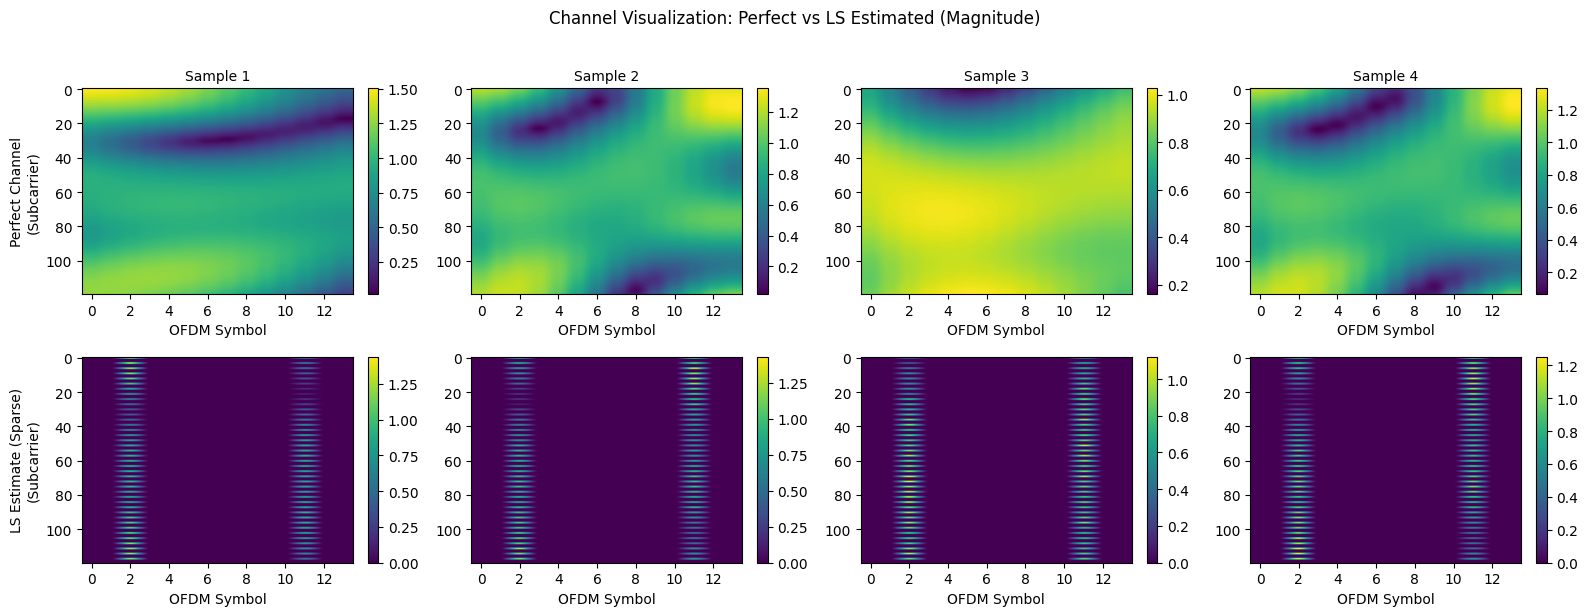

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# Get 4 random samples from validation set
sample_files = list(VAL_DIR.glob("*.mat"))[:4]

fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for col, mat_file in enumerate(sample_files):
    data = sio.loadmat(mat_file)
    H = data['H']
    
    # Perfect channel (H[:,:,0]) - top row
    perfect_channel = np.abs(H[:, :, 0])
    im0 = axes[0, col].imshow(perfect_channel, aspect='auto', cmap='viridis')
    axes[0, col].set_title(f'Sample {col+1}', fontsize=10)
    if col == 0:
        axes[0, col].set_ylabel('Perfect Channel\n(Subcarrier)', fontsize=10)
    axes[0, col].set_xlabel('OFDM Symbol')
    axes[0, col].xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.colorbar(im0, ax=axes[0, col], fraction=0.046)
    
    # LS estimated sparse channel (H[:,:,1]) - bottom row
    ls_channel = np.abs(H[:, :, 1])
    im1 = axes[1, col].imshow(ls_channel, aspect='auto', cmap='viridis')
    if col == 0:
        axes[1, col].set_ylabel('LS Estimate (Sparse)\n(Subcarrier)', fontsize=10)
    axes[1, col].set_xlabel('OFDM Symbol')
    axes[1, col].xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.colorbar(im1, ax=axes[1, col], fraction=0.046)

plt.suptitle('Channel Visualization: Perfect vs LS Estimated (Magnitude)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()